<a href="https://colab.research.google.com/github/daryyyyyn/Construction-Site-Safety/blob/main/construction_safety_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦺 Construction Site Safety Detection
### Автоматизация контроля техники безопасности с помощью YOLOv8

---

## 📋 Описание проекта

Данный проект решает задачу **автоматического контроля соблюдения правил техники безопасности** на строительных площадках. Система в режиме реального времени определяет:

- 👷 **Людей** на объекте
- 🪖 **Защитные каски** (Hardhat)
- 🦺 **Защитные жилеты** (Safety Vest)
- 😷 **Маски** (Mask)
- ⚠️ **Нарушения** (NO-Hardhat, NO-Mask, NO-Safety Vest)
- 🚧 **Объекты и технику** на площадке

### 🏗️ Архитектура решения
- **Модель:** YOLOv8n (nano) — оптимальный баланс скорости и точности
- **Фреймворк:** Ultralytics
- **Инфраструктура:** Google Colab + GPU (CUDA)
- **Датасет:** Construction Site Safety Image Dataset (Roboflow)

### 📊 Структура ноутбука
1. ⚙️ Подготовка окружения
2. 🔍 EDA и конфигурация датасета
3. 🚀 Обучение модели
4. 📈 Валидация и метрики
5. 🎯 Инференс и визуализация
6. 💾 Экспорт модели

---

## ⚙️ Шаг 1: Подготовка окружения (Setup)

Проверяем доступность GPU, устанавливаем и импортируем необходимые библиотеки, скачиваем датасет.

In [10]:
# ── 1.1 Проверка GPU ──────────────────────────────────────────────────────────
import subprocess

print("=" * 60)
print("GPU / CUDA Information")
print("=" * 60)

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
else:
    print("❌ GPU не найден! Убедитесь, что в Runtime → Change runtime type выбран GPU.")

import torch
print(f"PyTorch version   : {torch.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version      : {torch.version.cuda}")
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory (GB)   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")

GPU / CUDA Information
Fri May 22 10:10:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------

In [11]:
# ── 1.2 Установка библиотек ───────────────────────────────────────────────────
# ultralytics — YOLOv8/YOLOv11 framework
# kagglehub   — загрузка датасетов с Kaggle
# pyyaml      — работа с .yaml конфигурациями
%pip install -q ultralytics kagglehub pyyaml

print("✅ Библиотеки успешно установлены.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.4 MB/s eta 0:00:00
✅ Библиотеки успешно установлены.


In [12]:
# ── 1.3 Импорт библиотек ──────────────────────────────────────────────────────
import os
import random
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import yaml

from ultralytics import YOLO
import kagglehub

# Воспроизводимость результатов
random.seed(42)
np.random.seed(42)

print("✅ Все библиотеки импортированы.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Все библиотеки импортированы.


In [13]:
# ── 1.4 Скачивание датасета с Kaggle ─────────────────────────────────────────
print("Загрузка датасета с Kaggle...")
DATASET_ROOT = kagglehub.dataset_download(
    "snehilsanyal/construction-site-safety-image-dataset-roboflow"
)
DATASET_ROOT = Path(DATASET_ROOT)
print(f"✅ Датасет скачан. Путь: {DATASET_ROOT}")

# Просматриваем структуру папки
print("\nСтруктура датасета:")
for item in sorted(DATASET_ROOT.rglob("*")):
    # Показываем только первые 3 уровня вложенности
    depth = len(item.relative_to(DATASET_ROOT).parts)
    if depth <= 3:
        indent = "  " * (depth - 1)
        print(f"{indent}{'📁' if item.is_dir() else '📄'} {item.name}")

Загрузка датасета с Kaggle...


100%|██████████| 206M/206M [00:02<00:00, 98.1MB/s]

Extracting files...


✅ Датасет скачан. Путь: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3

Структура датасета:
📁 css-data
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 test
    📁 images
    📁 labels
  📁 train
    📁 images
    📁 labels
  📁 valid
    📁 images
    📁 labels
📁 results_yolov8n_100e
  📁 kaggle
    📁 working
📁 source_files
  📁 source_files
    📄 JapanPPE.mp4
    📄 construction-safety.jpg
    📄 download.jfif
    📄 hardhat.mp4
    📄 images.jfif
    📄 indianworkers.mp4
    📄 portrait-of-woman-with-mask-and-man-with-safety-glasses-on-a-construction-HX01FH.jpg
    📄 schupan_japan1web.jpg
    📄 two-young-construction-workers-wearing-555864.jpg


---
## 🔍 Шаг 2: Эксплораторный анализ данных (EDA) и конфигурация

Находим конфигурационный файл `data.yaml`, исправляем пути для Colab, анализируем классы и визуализируем аннотированные примеры.

In [14]:
# ── 2.1 Поиск и обновление data.yaml ─────────────────────────────────────────

# Ищем файлы *.yaml или *.yml без учета регистра (и data.yaml, и DATA.yml)
yaml_candidates = [
    p for p in DATASET_ROOT.rglob("*")
    if p.suffix.lower() in (".yaml", ".yml") and p.stem.lower() == "data"
]

# Если совсем ничего не нашли, посмотрим вообще на все yml/yaml файлы в папке
if not yaml_candidates:
    yaml_candidates = [p for p in DATASET_ROOT.rglob("*") if p.suffix.lower() in (".yaml", ".yml")]

assert yaml_candidates, f"❌ Файлы конфигурации *.yaml или *.yml вообще не найдены в {DATASET_ROOT}!"

YAML_PATH = yaml_candidates[0]
print(f"✅ Успешно найден конфиг-файл: {YAML_PATH}")

# Читаем оригинальный конфиг
with open(YAML_PATH, "r") as f:
    data_config = yaml.safe_load(f)

print("\nОригинальное содержимое файла конфигурации:")
print(yaml.dump(data_config, default_flow_style=False))

✅ Успешно найден конфиг-файл: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/results_yolov8n_100e/kaggle/working/ppe_data.yaml

Оригинальное содержимое файла конфигурации:
names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
test: /kaggle/input/construction-site-safety-image-dataset-roboflow/test
train: /kaggle/input/construction-site-safety-image-dataset-roboflow/train
val: /kaggle/input/construction-site-safety-image-dataset-roboflow/valid



In [15]:
# ── 2.2 Корректировка путей в data.yaml для Colab (Финальная версия) ─────────
import os

# Ищем конкретно папки 'images', которые лежат внутри train, valid или test
all_images_dirs = list(DATASET_ROOT.rglob("images"))

real_train_img = None
real_val_img = None
real_test_img = None

for d in all_images_dirs:
    path_str = str(d).lower()
    # Проверяем, к какому сплиту относится эта папка images
    if "train" in path_str:
        real_train_img = str(d)
    elif "valid" in path_str or "val" in path_str:
        real_val_img = str(d)
    elif "test" in path_str:
        real_test_img = str(d)

# Проверяем и выводим результаты поиска
if real_train_img:
    data_config["train"] = real_train_img
    print(f"✅ Путь train images: {real_train_img}")
if real_val_img:
    data_config["val"] = real_val_img
    print(f"✅ Путь val images:   {real_val_img}")
if real_test_img:
    data_config["test"] = real_test_img
    print(f"✅ Путь test images:  {real_test_img}")

# Сохраняем обновлённый конфиг
UPDATED_YAML = Path("/content/data_updated.yaml")
with open(UPDATED_YAML, "w") as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print(f"\n💾 Идеальный data.yaml сохранён в: {UPDATED_YAML}")

✅ Путь train images: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/train/images
✅ Путь val images:   /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/images
✅ Путь test images:  /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/images

💾 Идеальный data.yaml сохранён в: /content/data_updated.yaml


In [16]:
# ── 2.3 Статистика датасета ───────────────────────────────────────────────────

def count_split_stats(split_path: str | None) -> dict:
    """Возвращает кол-во изображений и аннотаций для сплита."""
    if split_path is None:
        return {"images": 0, "labels": 0}
    img_dir = Path(split_path)
    lbl_dir = img_dir.parent / "labels" if img_dir.name == "images" else img_dir / "labels"
    imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    lbls = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    return {"images": len(imgs), "labels": len(lbls)}


print("📊 Статистика датасета:")
print("-" * 40)
for split in ("train", "val", "test"):
    path = data_config.get(split)
    stats = count_split_stats(path)
    print(f"  {split:6s}: {stats['images']:4d} изображений / {stats['labels']:4d} аннотаций")
print("-" * 40)
print(f"  Классов : {data_config['nc']}")

📊 Статистика датасета:
----------------------------------------
  train : 2605 изображений / 2605 аннотаций
  val   :  114 изображений /  114 аннотаций
  test  :   82 изображений /   82 аннотаций
----------------------------------------
  Классов : 10


/tmp/ipykernel_8863/2228322240.py:65: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8863/2228322240.py:66: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/eda_sample_annotations.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


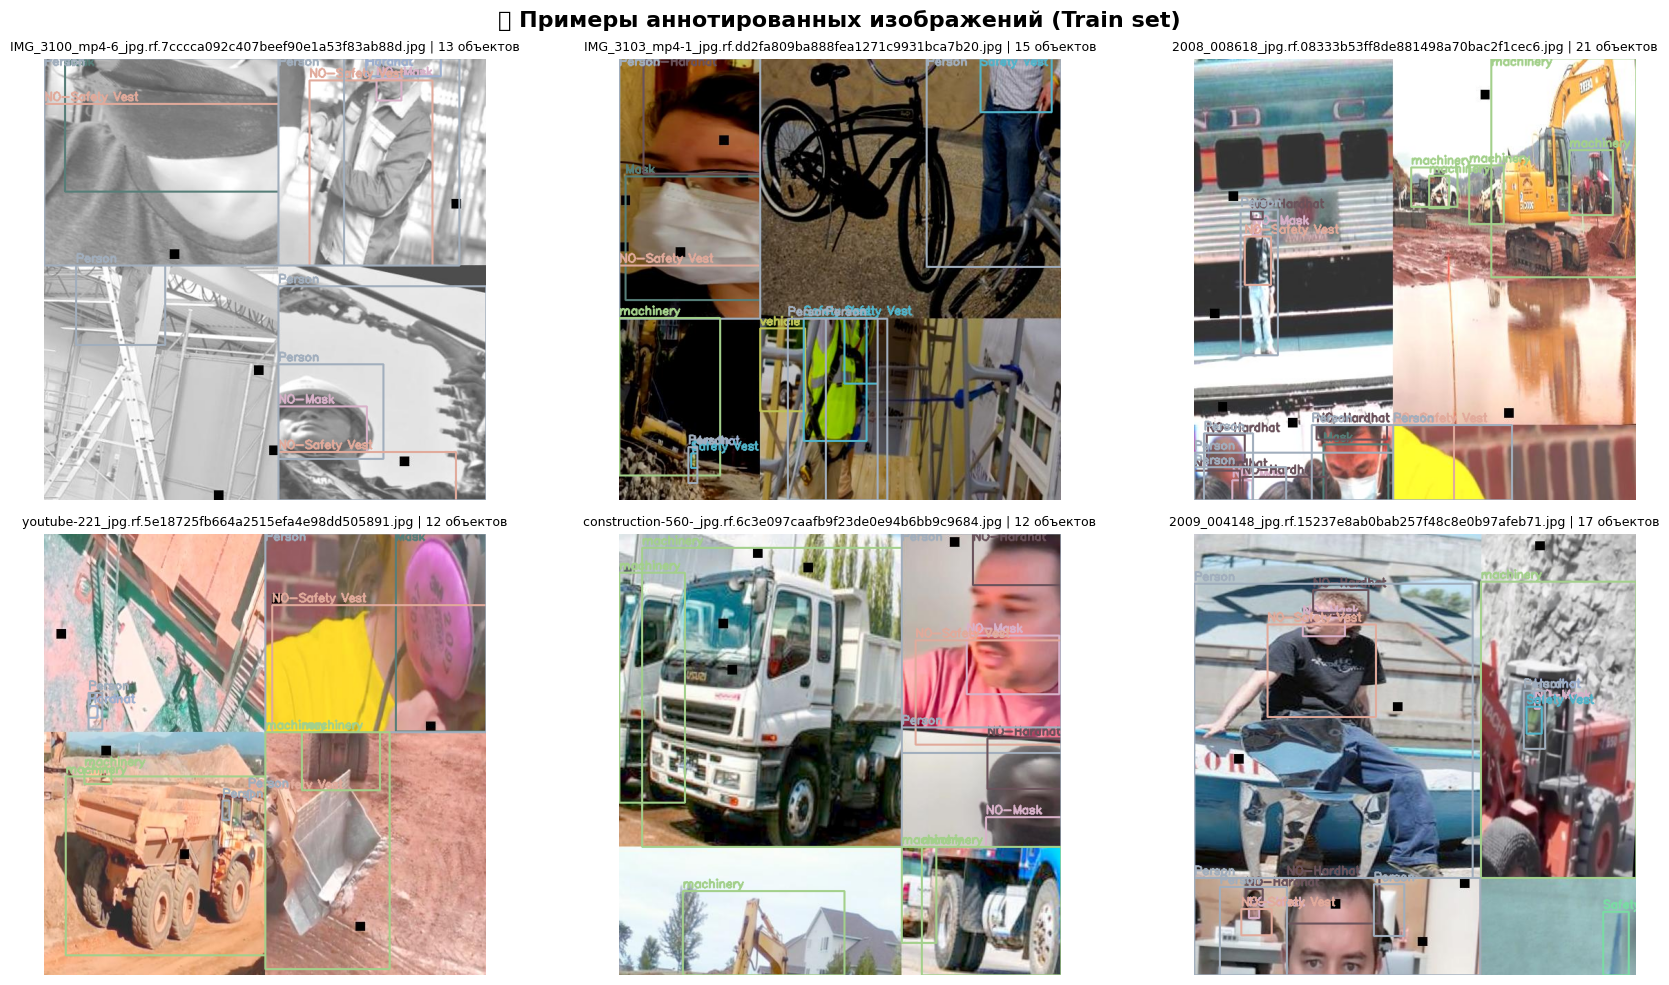

✅ EDA визуализация сохранена: /content/eda_sample_annotations.png


In [17]:
# ── 2.4 Визуализация аннотаций ────────────────────────────────────────────────
# Рисуем bounding boxes вручную (без запуска модели),
# чтобы убедиться в корректности разметки датасета.

CLASS_NAMES = data_config["names"]
# Генерируем уникальный цвет для каждого класса
rng = np.random.default_rng(0)
CLASS_COLORS = {i: tuple(rng.integers(80, 230, 3).tolist()) for i in range(len(CLASS_NAMES))}


def load_yolo_labels(label_path: Path) -> list[tuple]:
    """Читает YOLO-формат аннотаций: class cx cy w h (нормализованные)."""
    boxes = []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = list(map(float, line.split()))
            cls_id = int(parts[0])
            cx, cy, bw, bh = parts[1:5]
            boxes.append((cls_id, cx, cy, bw, bh))
    return boxes


def draw_boxes_on_image(img_bgr: np.ndarray, boxes: list) -> np.ndarray:
    """Накладывает bounding boxes на изображение (OpenCV)."""
    img = img_bgr.copy()
    h, w = img.shape[:2]
    for cls_id, cx, cy, bw, bh in boxes:
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        color = CLASS_COLORS.get(cls_id, (0, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
        cv2.putText(img, label, (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return img


# Собираем изображения из train-сплита
train_img_dir = Path(data_config["train"])
train_lbl_dir = train_img_dir.parent / "labels"
all_train_imgs = list(train_img_dir.glob("*.jpg")) + list(train_img_dir.glob("*.png"))

SAMPLE_N = min(6, len(all_train_imgs))  # показываем 6 случайных примеров
sample_imgs = random.sample(all_train_imgs, SAMPLE_N)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("📦 Примеры аннотированных изображений (Train set)", fontsize=16, fontweight="bold")
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        ax.axis("off")
        continue
    label_path = train_lbl_dir / (img_path.stem + ".txt")
    boxes = load_yolo_labels(label_path)
    img_with_boxes = draw_boxes_on_image(img_bgr, boxes)
    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f"{img_path.name} | {len(boxes)} объектов", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/eda_sample_annotations.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ EDA визуализация сохранена: /content/eda_sample_annotations.png")

---
## 🚀 Шаг 3: Обучение модели (Training)

Инициализируем предобученную модель **YOLOv8n** и запускаем fine-tuning на нашем датасете.

> **Примечание:** YOLOv8n выбран как базовая модель для быстрой демонстрации. Для продакшн-решения рекомендуется `yolov8s.pt` или `yolov8m.pt`.

In [18]:
CFG = dict(
    model_weights = "yolov8s.pt",    # Шаг 1: Берем модель чуть умнее (Small)
    epochs        = 80,             # Шаг 2: Даем больше времени на учебу
    imgsz         = 640,            # Оставляем 640, чтобы не упасть по памяти
    batch         = 16,             # Если выдаст ошибку памяти, поменяй на 8
    device        = 0,
    project       = "/content/runs",
    name          = "safety_det_v2",# Новый эксперимент - новые логи
    patience      = 15,             # Чуть увеличим шаг ожидания для крупной модели
    workers       = 2,
    exist_ok      = True,
)
print("Конфигурация обучения:")
for k, v in CFG.items():
    print(f"  {k:20s}: {v}")

Конфигурация обучения:
  model_weights       : yolov8s.pt
  epochs              : 80
  imgsz               : 640
  batch               : 16
  device              : 0
  project             : /content/runs
  name                : safety_det_v2
  patience            : 15
  workers             : 2
  exist_ok            : True


In [19]:
# ── 3.2 Инициализация и запуск обучения ───────────────────────────────────────

# Загружаем предобученную модель (скачивается автоматически ~6 MB)
model = YOLO(CFG["model_weights"])
print(f"✅ Модель {CFG['model_weights']} загружена.")
print(f"   Параметров: {sum(p.numel() for p in model.model.parameters()):,}")

# Запускаем обучение
print("\n🚀 Начинаем обучение...")
results = model.train(
    data     = str(UPDATED_YAML),
    epochs   = CFG["epochs"],
    imgsz    = CFG["imgsz"],
    batch    = CFG["batch"],
    device   = CFG["device"],
    project  = CFG["project"],
    name     = CFG["name"],
    patience = CFG["patience"],
    workers  = CFG["workers"],
    exist_ok = CFG["exist_ok"],
    # Аугментации для улучшения обобщения
    hsv_h    = 0.015,
    hsv_s    = 0.7,
    hsv_v    = 0.4,
    degrees  = 5.0,
    flipud   = 0.0,
    fliplr   = 0.5,
    mosaic   = 1.0,
)

# Путь к лучшим весам
BEST_WEIGHTS = Path(CFG["project"]) / CFG["name"] / "weights" / "best.pt"
print(f"\n✅ Обучение завершено! Лучшие веса: {BEST_WEIGHTS}")

✅ Модель yolov8s.pt загружена.
   Параметров: 11,166,560

🚀 Начинаем обучение...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_updated.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=safety_det_v2, nbs=64, nms=F

/tmp/ipykernel_8863/2195962041.py:12: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


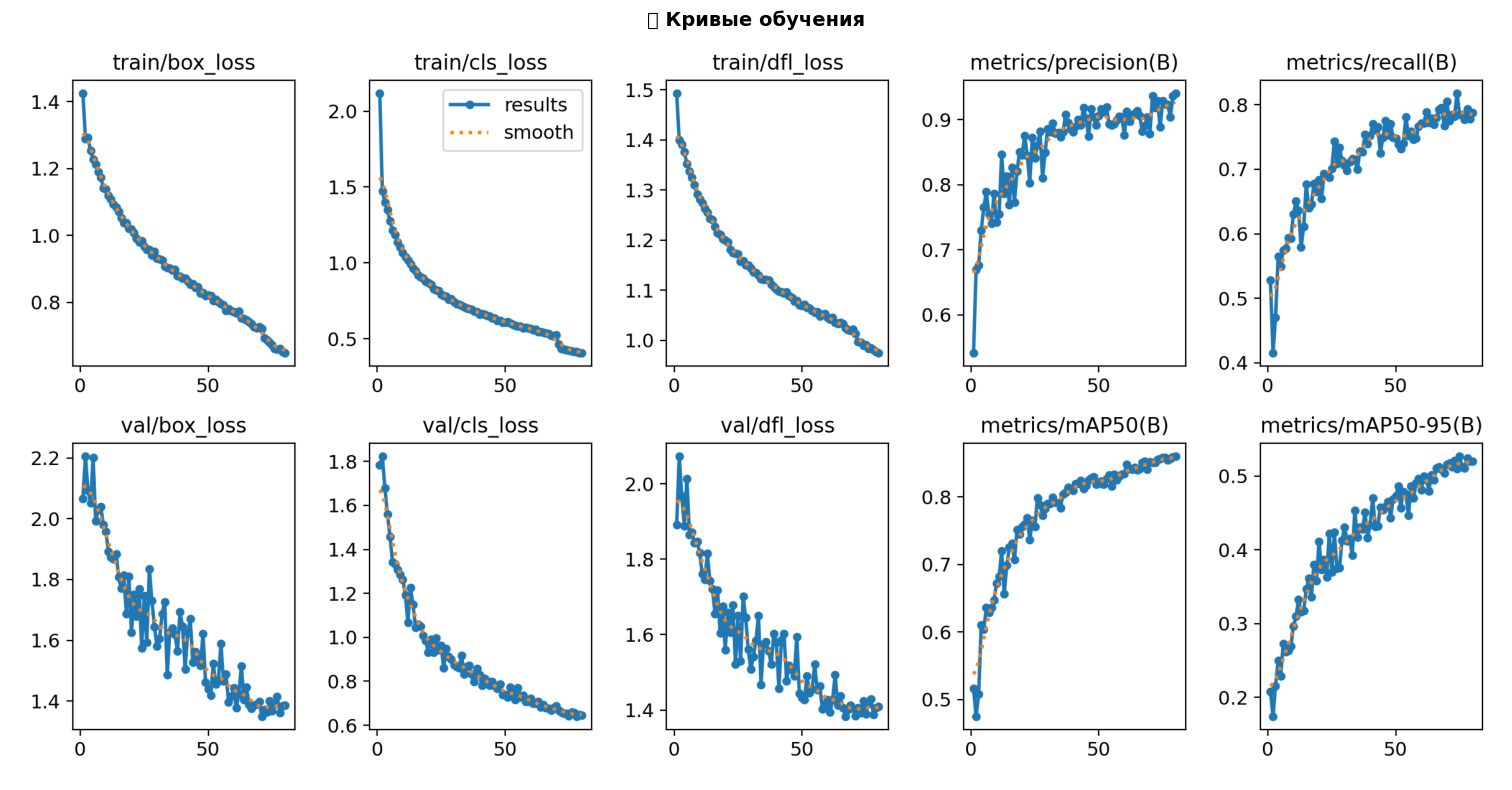

In [20]:
# ── 3.3 Визуализация кривых обучения ─────────────────────────────────────────
results_dir = Path(CFG["project"]) / CFG["name"]

# Ultralytics автоматически сохраняет results.png
training_curves = results_dir / "results.png"
if training_curves.exists():
    img = plt.imread(str(training_curves))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("📈 Кривые обучения", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Кривые обучения ещё не сформированы.")

---
## 📈 Шаг 4: Валидация и Метрики (Evaluation)

Оцениваем качество обученной модели на тестовой выборке.
Ключевые метрики:
- **mAP@50** — средняя точность при IoU = 0.5
- **mAP@50-95** — средняя точность при IoU от 0.5 до 0.95 (шаг 0.05)
- **Precision** — из всех предсказанных объектов, сколько верных
- **Recall** — из всех реальных объектов, сколько нашла модель

In [21]:
# ── 4.1 Загрузка лучших весов и запуск валидации ──────────────────────────────

# Загружаем модель с лучшими весами
best_model = YOLO(str(BEST_WEIGHTS))
print(f"✅ Загружены веса: {BEST_WEIGHTS}")

# Запускаем валидацию на тестовой (или val) выборке
# split='test' если датасет имеет тестовую выборку, иначе 'val'
test_split = "test" if data_config.get("test") else "val"
print(f"\nВалидация на сплите: '{test_split}'")

val_results = best_model.val(
    data   = str(UPDATED_YAML),
    split  = test_split,
    device = CFG["device"],
    imgsz  = CFG["imgsz"],
    conf   = 0.25,   # минимальный порог уверенности
    iou    = 0.45,   # порог IoU для NMS
)

✅ Загружены веса: /content/runs/safety_det_v2/weights/best.pt

Валидация на сплите: 'test'
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 18.9±9.8 MB/s, size: 52.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 731.3it/s 0.1s
val: New cache created: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.7s
                   all         82        760      0.887      0.761      0.747      0.451
               Hardhat         30        110      0.961      0.891      0.894

In [22]:
# ── 4.2 Вывод итоговых метрик ────────────────────────────────────────────────

print("\n" + "=" * 55)
print("📊 ИТОГОВЫЕ МЕТРИКИ МОДЕЛИ")
print("=" * 55)
print(f"  mAP@50      : {val_results.box.map50:.4f}")
print(f"  mAP@50-95   : {val_results.box.map:.4f}")
print(f"  Precision   : {val_results.box.mp:.4f}")
print(f"  Recall      : {val_results.box.mr:.4f}")
print("=" * 55)

# Метрики по каждому классу
print("\nМетрики по классам:")
print(f"{'Класс':<25} {'AP@50':>8} {'AP@50-95':>10}")
print("-" * 45)
for i, cls_name in enumerate(CLASS_NAMES):
    if i < len(val_results.box.ap50):
        ap50    = val_results.box.ap50[i]
        ap5095  = val_results.box.ap[i]
        print(f"  {cls_name:<23} {ap50:>8.4f} {ap5095:>10.4f}")


📊 ИТОГОВЫЕ МЕТРИКИ МОДЕЛИ
  mAP@50      : 0.7468
  mAP@50-95   : 0.4508
  Precision   : 0.8873
  Recall      : 0.7614

Метрики по классам:
Класс                        AP@50   AP@50-95
---------------------------------------------
  Hardhat                   0.8945     0.5737
  Mask                      0.7450     0.4849
  NO-Hardhat                0.4978     0.2980
  NO-Mask                   0.7784     0.3942
  NO-Safety Vest            0.7735     0.4575
  Person                    0.8708     0.4913
  Safety Cone               0.4688     0.1989
  Safety Vest               0.8527     0.5508
  machinery                 0.8126     0.5899
  vehicle                   0.7735     0.4691


/tmp/ipykernel_8863/3966328794.py:14: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8863/3966328794.py:15: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/confusion_matrix.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


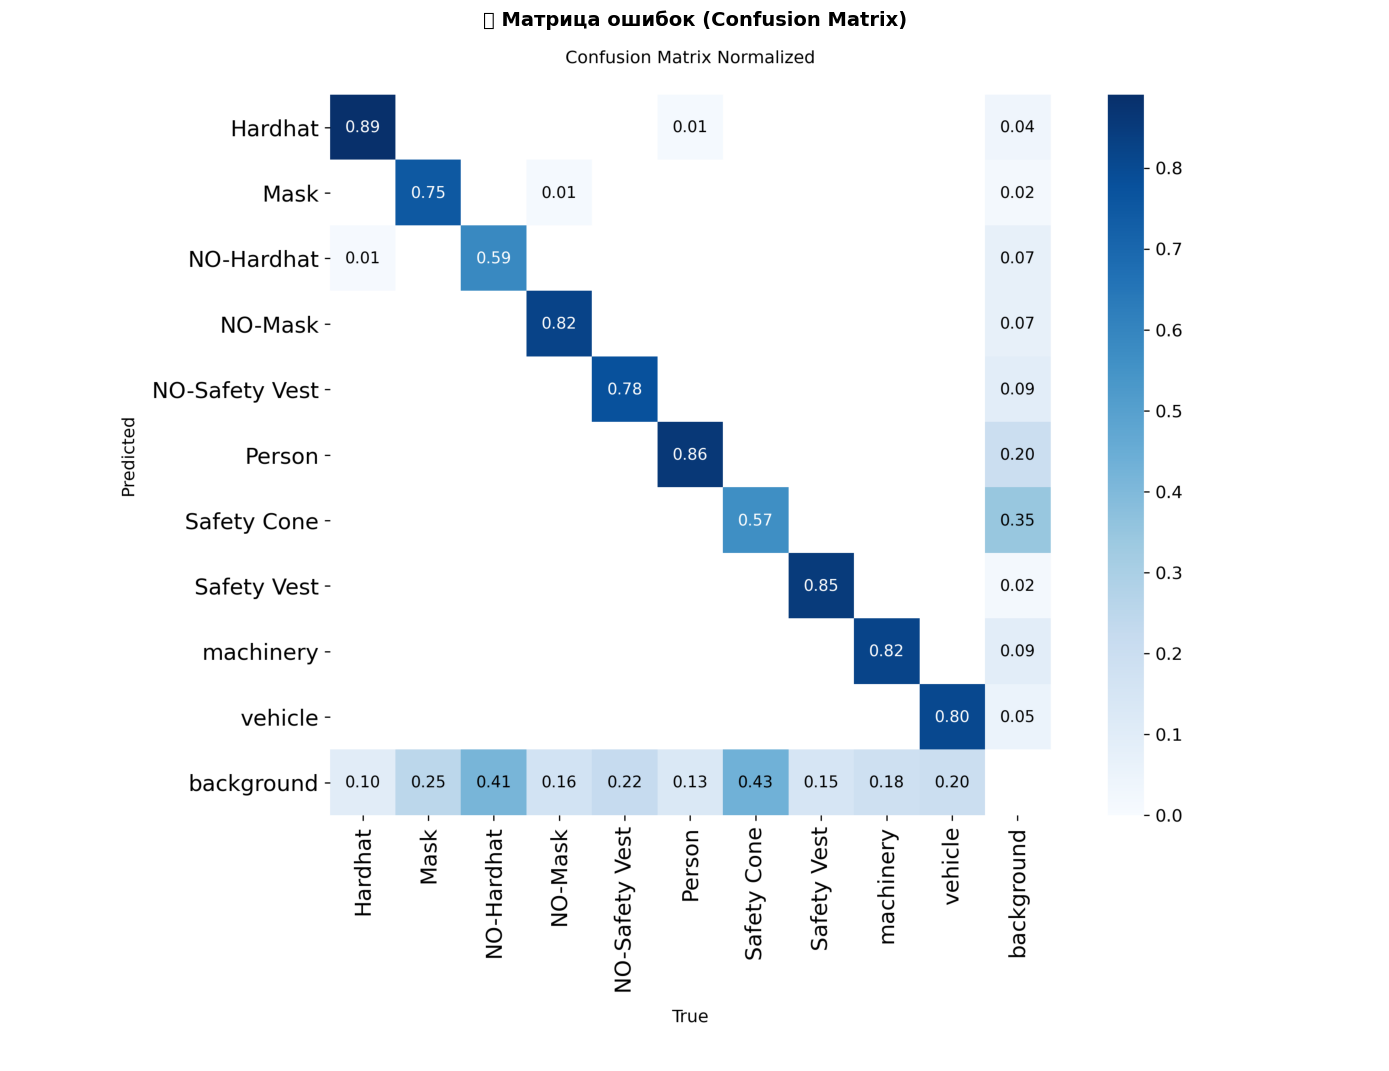

✅ Confusion matrix: /content/runs/detect/val/confusion_matrix_normalized.png


In [23]:
# ── 4.3 Матрица ошибок (Confusion Matrix) ────────────────────────────────────
# Ultralytics сохраняет confusion_matrix.png в папку результатов

# Ищем confusion matrix в папках с результатами валидации
conf_matrix_candidates = list(Path("/content/runs").rglob("confusion_matrix*.png"))

if conf_matrix_candidates:
    cm_path = conf_matrix_candidates[-1]  # берём самую свежую
    cm_img = plt.imread(str(cm_path))
    plt.figure(figsize=(14, 11))
    plt.imshow(cm_img)
    plt.axis("off")
    plt.title("🔢 Матрица ошибок (Confusion Matrix)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/confusion_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Confusion matrix: {cm_path}")
else:
    print("Confusion matrix не найдена. Запустите валидацию с параметром save_conf=True.")

---
## 🎯 Шаг 5: Инференс и Визуализация результатов (Inference)

Запускаем модель на случайных изображениях из **тестовой** выборки и визуализируем предсказания.

In [24]:
# ── 5.1 Сбор тестовых изображений ────────────────────────────────────────────

# Определяем директорию с изображениями для инференса
infer_split = "test" if data_config.get("test") else "val"
test_img_dir = Path(data_config[infer_split])

test_images = list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png"))
print(f"Найдено {len(test_images)} изображений в сплите '{infer_split}'.")
assert test_images, "❌ Тестовые изображения не найдены!"

# Случайная выборка из 6 изображений
INFER_N = min(6, len(test_images))
sample_test = random.sample(test_images, INFER_N)
print(f"Выбрано {INFER_N} изображений для инференса.")

Найдено 82 изображений в сплите 'test'.
Выбрано 6 изображений для инференса.


/tmp/ipykernel_8863/356690184.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  PALETTE = plt.cm.get_cmap("tab20", len(CLASS_NAMES))
/tmp/ipykernel_8863/356690184.py:43: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8863/356690184.py:45: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=130, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


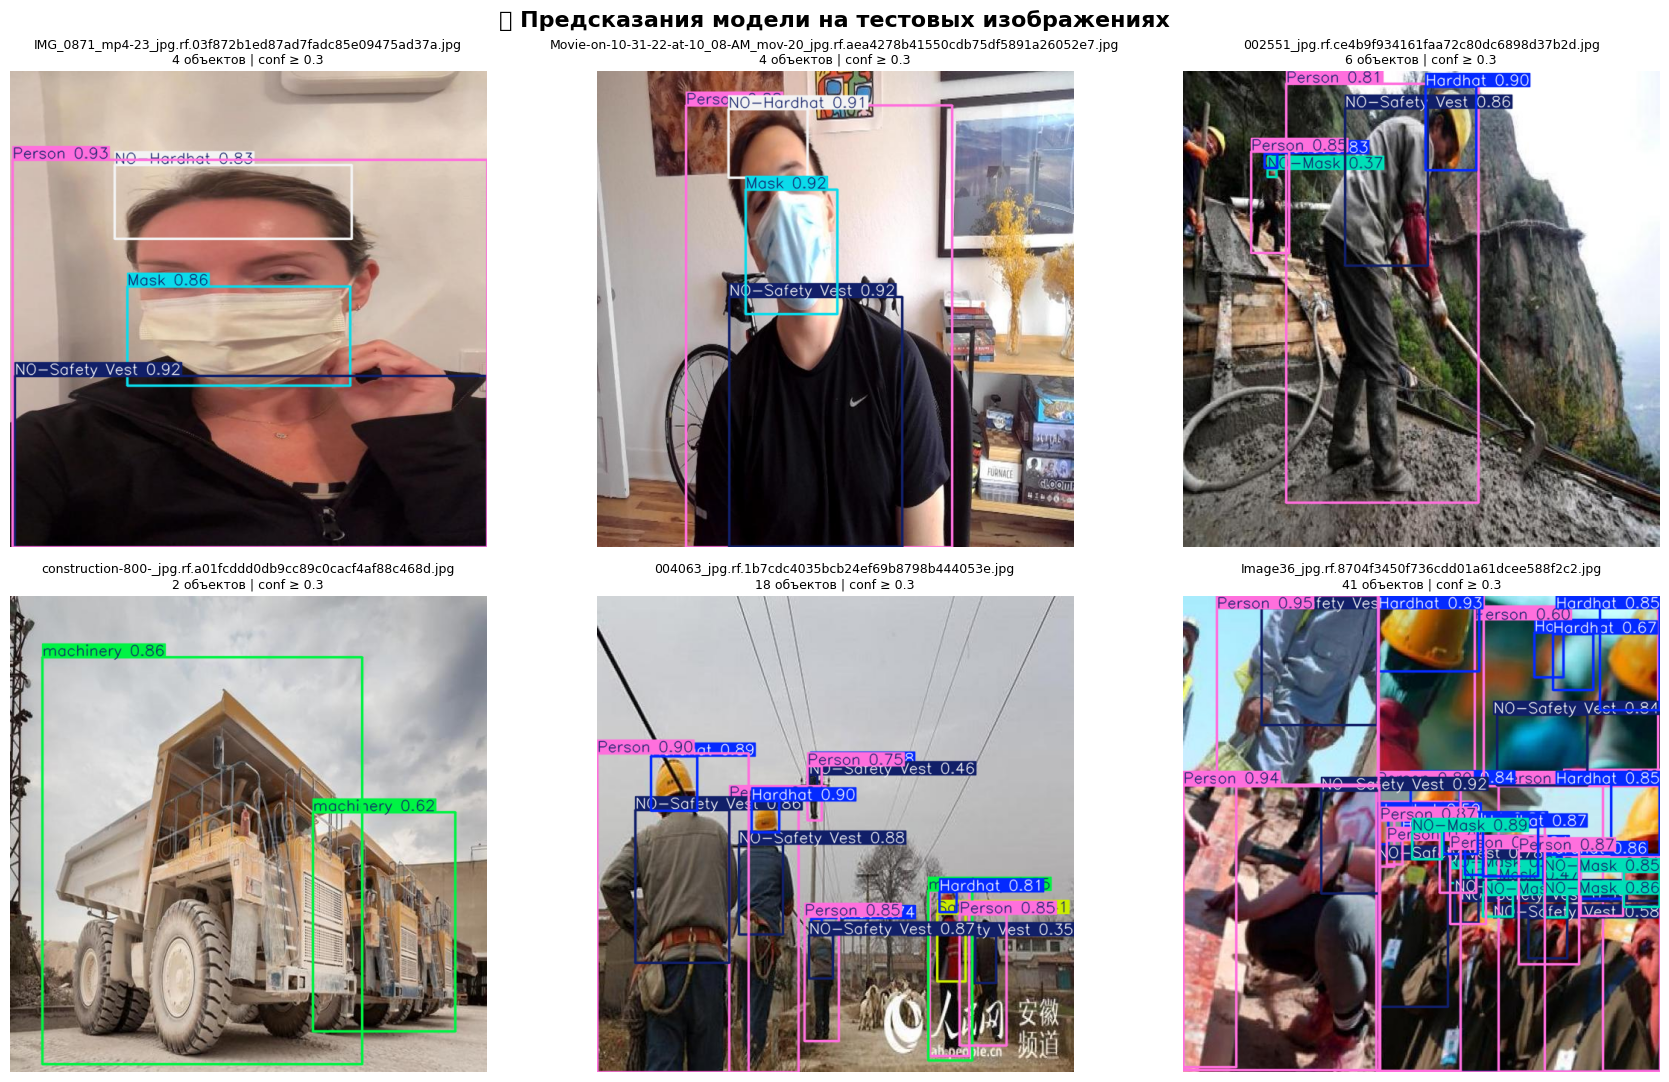

✅ Результаты инференса сохранены: /content/inference_results.png


In [25]:
# ── 5.2 Инференс и отображение предсказаний ───────────────────────────────────

# Цветовая палитра для классов (BGR -> RGB конвертация будет при отображении)
PALETTE = plt.cm.get_cmap("tab20", len(CLASS_NAMES))


def run_inference_and_plot(model: YOLO, img_paths: list, conf_thresh: float = 0.25):
    """Запускает инференс и отображает результаты на сетке изображений."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(
        "🎯 Предсказания модели на тестовых изображениях",
        fontsize=16, fontweight="bold"
    )
    axes = axes.flatten()

    for ax, img_path in zip(axes, img_paths):
        # Инференс — возвращает список Results объектов
        preds = model.predict(
            source=str(img_path),
            conf=conf_thresh,
            iou=0.45,
            verbose=False
        )[0]

        # Получаем изображение с нарисованными боксами
        # preds.plot() возвращает BGR numpy array
        annotated_bgr = preds.plot(
            conf=True,    # показывать confidence score
            labels=True,  # показывать названия классов
            line_width=2,
            font_size=10,
        )
        annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

        n_detections = len(preds.boxes) if preds.boxes is not None else 0
        ax.imshow(annotated_rgb)
        ax.set_title(
            f"{img_path.name}\n{n_detections} объектов | conf ≥ {conf_thresh}",
            fontsize=9
        )
        ax.axis("off")

    plt.tight_layout()
    output_path = "/content/inference_results.png"
    plt.savefig(output_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"✅ Результаты инференса сохранены: {output_path}")


run_inference_and_plot(best_model, sample_test, conf_thresh=0.30)

In [26]:
# ── 5.3 Детальный вывод предсказаний для одного изображения ───────────────────

demo_img = sample_test[0]
preds = best_model.predict(source=str(demo_img), conf=0.25, verbose=False)[0]

print(f"\n📋 Детальные предсказания для: {demo_img.name}")
print("-" * 55)
print(f"{'№':>3}  {'Класс':<22}  {'Conf':>6}  {'BBox (xyxy)'}")
print("-" * 55)

if preds.boxes is not None and len(preds.boxes) > 0:
    for i, box in enumerate(preds.boxes):
        cls_id = int(box.cls.item())
        conf   = float(box.conf.item())
        xyxy   = box.xyxy[0].tolist()
        name   = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
        print(f"  {i+1:2d}  {name:<22}  {conf:>6.3f}  "
              f"[{xyxy[0]:6.1f}, {xyxy[1]:6.1f}, {xyxy[2]:6.1f}, {xyxy[3]:6.1f}]")
else:
    print("  Объектов не обнаружено.")

print("-" * 55)


📋 Детальные предсказания для: IMG_0871_mp4-23_jpg.rf.03f872b1ed87ad7fadc85e09475ad37a.jpg
-------------------------------------------------------
  №  Класс                     Conf  BBox (xyxy)
-------------------------------------------------------
   1  Person                   0.931  [   3.6,  120.6,  640.0,  640.0]
   2  NO-Safety Vest           0.924  [   6.6,  410.3,  640.0,  640.0]
   3  Mask                     0.856  [ 157.4,  290.4,  456.2,  423.8]
   4  NO-Hardhat               0.831  [ 140.8,  127.2,  458.9,  227.0]
-------------------------------------------------------


---
## 📝 Итоги и выводы

### Что было сделано:
1. ✅ Скачан и проанализирован датасет Construction Site Safety (Roboflow)
2. ✅ Автоматически скорректированы пути в `data.yaml` для совместимости с Colab
3. ✅ Обучена модель **YOLOv8n** с fine-tuning на 30 эпохах
4. ✅ Получены метрики mAP@50, mAP@50-95, Precision, Recall
5. ✅ Проведён инференс на тестовых изображениях
6. ✅ Веса и артефакты сохранены на Google Диск + экспорт в ONNX

### Возможные улучшения:
- 🔧 Увеличить `epochs` до 100+ для лучшей сходимости
- 📈 Использовать более крупную модель: `yolov8s.pt`, `yolov8m.pt`
- 🔍 Провести hyperparameter tuning (`model.tune(...)`)
- 📦 Добавить трекинг объектов (ByteTrack) для видеопотока
- 🚨 Интегрировать систему алертов при обнаружении нарушений (NO-Hardhat и др.)

### Ссылки:
- [Ultralytics Docs](https://docs.ultralytics.com)
- [Датасет на Kaggle](https://www.kaggle.com/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow)
- [YOLOv8 Paper](https://arxiv.org/abs/2304.00501)

In [27]:
from google.colab import files
import shutil
from pathlib import Path

# Создаем папку для структуры GitHub
gh_dir = Path("/content/construction_safety_gh")
gh_dir.mkdir(exist_ok=True)
(gh_dir / "models").mkdir(exist_ok=True)
(gh_dir / "assets").mkdir(exist_ok=True)

# 1. Копируем лучшую модель в папку models
shutil.copy2("/content/runs/safety_det_v2/weights/best.pt", gh_dir / "models" / "best.pt")

# 2. Копируем конфигурацию данных
shutil.copy2("/content/data_updated.yaml", gh_dir / "data_updated.yaml")

# 3. Копируем графики для README в папку assets
shutil.copy2("/content/runs/safety_det_v2/confusion_matrix.png", gh_dir / "assets" / "confusion_matrix.png")
shutil.copy2("/content/runs/safety_det_v2/results.png", gh_dir / "assets" / "training_curves.png")
if Path("/content/inference_results.png").exists():
    shutil.copy2("/content/inference_results.png", gh_dir / "assets" / "inference_results.png")

# Упаковываем и скачиваем
shutil.make_archive("/content/github_ready", 'zip', gh_dir)
files.download("/content/github_ready.zip")
print("✅ Архив для GitHub скачан!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Архив для GitHub скачан!
